# EDA - Campeonato Brasileiro (2003–2023)

Este notebook carrega os 4 datasets do projeto, trata os dados brutos e conduz a análise exploratória de dados (EDA) que fundamenta as próximas etapas.

Ordem: carga → limpeza → diagnóstico de qualidade → **tratamento e exportação** → estatística descritiva → análises. O tratamento vem antes das análises para que todas usem a mesma base e as mesmas regras.

**Fonte dos dados:** Campeonato Brasileiro (2003–2023), dataset público do Kaggle. Link de acesso: https://www.kaggle.com/datasets/adaoduque/campeonato-brasileiro-de-futebol. Data de download: 15 de setembro de 2026.


## 1. Setup e Carga dos Dados

Leitura dos 4 CSVs (Partidas, Gols, Cartões e Estatísticas) e conferência das dimensões de cada um, para uso nas seções seguintes.

A base é restrita a 2003–2023, período coberto pela fonte utilizada. Também definimos aqui a constante `ANOS_VALIDOS` — as temporadas com coleta real de estatísticas de jogo, justificada na Seção 3.


In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COLORS = ["#1f6f5c", "#c0553a", "#3b6ea5", "#c9a227", "#7a5195"]

DATA_DIR = "../Datasets"
FIG_DIR  = "../figuras"
os.makedirs(FIG_DIR, exist_ok=True)

ANO_FINAL    = 2023
ANOS_VALIDOS = list(range(2015, 2024))

full = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-full.csv")
gols = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-gols.csv")
cartoes = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-cartoes.csv")
est = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-estatisticas-full.csv")

# Restrição ao período da fonte. As bases auxiliares são filtradas pelos IDs de
# partida que sobrevivem ao corte
full = full[pd.to_datetime(full["data"], dayfirst=True).dt.year <= ANO_FINAL].copy()
ids_validos = set(full["ID"])
gols = gols[gols["partida_id"].isin(ids_validos)].copy()
cartoes = cartoes[cartoes["partida_id"].isin(ids_validos)].copy()
est = est[est["partida_id"].isin(ids_validos)].copy()

for name, df in [("full", full), ("gols", gols), ("cartoes", cartoes), ("estatisticas", est)]:
    print(f"{name}: {df.shape[0]} linhas, {df.shape[1]} colunas")


full: 8405 linhas, 17 colunas
gols: 8932 linhas, 6 colunas
cartoes: 18857 linhas, 8 colunas
estatisticas: 16810 linhas, 13 colunas


## 2. Limpeza e Engenharia de Variáveis

Convertendo a data para datetime e extraindo o ano da temporada.

Criando as variáveis que serão usadas no resto do trabalho:
- `resultado` — Vitória Mandante / Empate / Vitória Visitante.
- `total_gols` e `saldo_mandante` — guardam a margem, que `resultado` descarta.

Convertendo `posse_de_bola` de texto ("53%") para float, senão qualquer média é impossível.

In [19]:
full["data"] = pd.to_datetime(full["data"], dayfirst=True)
full["ano"] = full["data"].dt.year

def classifica_resultado(row):
    if row["vencedor"] == "-":
        return "Empate"
    elif row["vencedor"] == row["mandante"]:
        return "Vitória Mandante"
    else:
        return "Vitória Visitante"

full["resultado"] = full.apply(classifica_resultado, axis=1)
full["total_gols"] = full["mandante_Placar"] + full["visitante_Placar"]
full["saldo_mandante"] = full["mandante_Placar"] - full["visitante_Placar"]

est["posse_de_bola"] = (
    est["posse_de_bola"].astype(str).str.replace("%", "", regex=False)
    .replace("nan", np.nan).astype(float)
)

full.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,ano,resultado,total_gols,saldo_mandante
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,...,Brinco de Ouro,4,2,SP,RJ,NaN,2003,Vitória Mandante,6,2
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,...,Arena da Baixada,2,0,PR,RS,NaN,2003,Vitória Mandante,2,2
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,...,Maracanã,1,1,RJ,PR,NaN,2003,Empate,2,0
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,...,Serra Dourada,2,2,GO,PA,NaN,2003,Empate,4,0
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,...,Beira Rio,1,1,RS,SP,NaN,2003,Empate,2,0


## 3. Verificação dos dados faltantes

Medindo o percentual de falta de dados por coluna em cada CSV, e depois a cobertura de `posse_de_bola` ano a ano.

O segundo gráfico existe para verificar o volume e período de ausência de `saldo_mandante`, para que utilizemos essa estatística restringindo um recorte temporal para o período onde os dados são presentes, para evitar viés de seleção, ou seja, não tratar como se fosse uma estatística geral.

In [20]:
for name, df in [("full", full), ("gols", gols), ("cartoes", cartoes), ("estatisticas", est)]:
    miss = df.isna().mean().mul(100).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{name} ({len(df)} linhas):")
    print(miss if len(miss) else "  (sem valores faltantes)")


full (8405 linhas):
arrecadacao           100.0
formacao_mandante      59.2
formacao_visitante     59.2
tecnico_mandante       54.8
tecnico_visitante      54.8
dtype: float64

gols (8932 linhas):
tipo_de_gol    87.8
dtype: float64

cartoes (18857 linhas):
posicao       6.4
num_camisa    2.0
dtype: float64

estatisticas (16810 linhas):
precisao_passes    73.2
posse_de_bola      59.4
dtype: float64


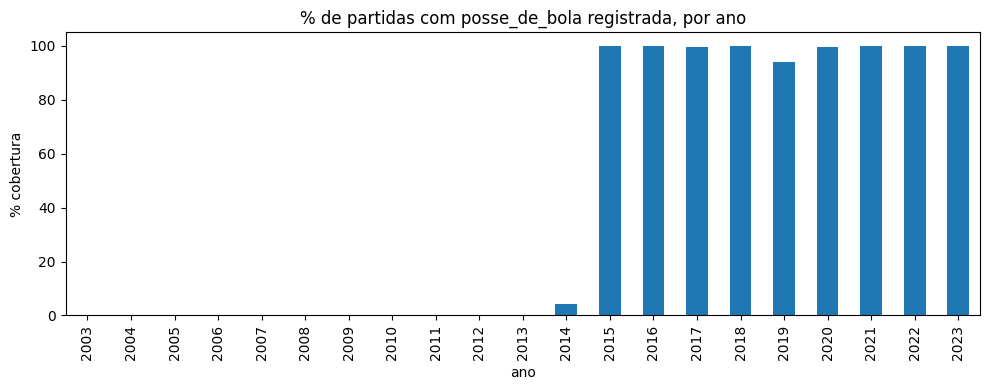

In [21]:
# posse_de_bola faltante por ano -- checar se há um recorte temporal confiável
est_ano = est.merge(full[["ID", "ano"]], left_on="partida_id", right_on="ID")
cobertura = est_ano.groupby("ano")["posse_de_bola"].apply(lambda s: 100 - s.isna().mean() * 100).round(1)
cobertura.plot(kind="bar", figsize=(10, 4), title="% de partidas com posse_de_bola registrada, por ano")
plt.ylabel("% cobertura")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cobertura_estatisticas.png", dpi=150)
plt.show()

### Resultado

| Período | Cobertura | Situação |
|---|---|---|
| 2003–2013 | 0% | sem coleta |
| 2014 | 4,2% | coleta iniciando, inutilizável |
| 2015–2023 | 93,9%–100% | válido |

A ausência é concentrada no tempo, e existe um agravante: nas temporadas sem coleta o valor gravado é `0`, não `NaN`. O pandas trata zero como observação legítima, então essas linhas **não aparecem** na contagem de faltantes acima e entram normalmente em qualquer média. A Seção 4, a seguir, corrige isso antes de qualquer análise.

Outras ausências: `arrecadacao` 100%, `formacao_*` 59,2%, `tecnico_*` 54,8% — justamente as colunas que permitiriam investigar gestão e escolha tática. Com metade ausente e concentrada nos anos antigos, tratamos isso em limitações, não como análise.

**Consequência — duas janelas:**
- Desfecho (resultado, gols, pontos): 2003–2023, 8.405 partidas.
- Como o jogo foi disputado (chutes, posse, faltas): 2015–2023, 3.419 partidas.

## 4. Tratamento do dataset

O diagnóstico da Seção 3 apontou três problemas: colunas com ausências em grande quantidade, zeros estruturais disfarçados de observação, e granularidades diferentes entre as bases. Esta seção aplica as correções e exporta um dataset único.

Regras de tratamento aplicadas:

1. **Colunas de baixa utilidade/alta ausência** (`arrecadacao`, `formacao_mandante/visitante`, `tecnico_mandante/visitante`) são descartadas do dataset tratado, por terem mais de 50% de valores faltantes concentrados nos anos iniciais. Ficam disponíveis no CSV bruto para quem quiser explorá-las.
2. **Zeros estruturais viram `NaN`**: para `chutes`, `chutes_no_alvo`, `passes`, `faltas`, `impedimentos`, `escanteios` e `posse_de_bola`, os anos sem coleta real (2003–2014) são marcados como ausentes em vez de zero.
3. **Cobertura das bases auxiliares:** as bases de gols e de cartões cobrem apenas 2014–2023. Nas temporadas anteriores não há registro algum, então `gols_penalti`, `gols_contra` e as colunas de cartão também ficam como ausentes em vez de zero — mesmo critério do item anterior. Dentro da janela coberta, uma partida sem pênalti ou sem cartão legitimamente vale 0.
4. Estatísticas de jogo e cartões são pivotados para o nível de partida (uma coluna por métrica × mandante/visitante), em vez de uma linha por time.
5. Gols são agregados por partida e por time, com contagem de pênaltis e gols contra. Em `tipo_de_gol`, o valor ausente significa "gol normal" — é a terceira categoria implícita, não dado faltante.


In [22]:
# Base da partida: colunas relevantes + variáveis criadas na Seção 2
colunas_base = [
    "ID", "data", "ano", "rodata", "mandante", "visitante",
    "mandante_Placar", "visitante_Placar", "resultado", "total_gols", "saldo_mandante",
    "vencedor", "arena", "mandante_Estado", "visitante_Estado"
]
tratado = full[colunas_base].rename(columns={
    "ID": "partida_id", "mandante_Placar": "gols_mandante", "visitante_Placar": "gols_visitante"
}).copy()

tratado.shape

(8405, 15)

In [23]:
# Gols por time e por tipo (pênalti / gol contra), agregados por partida
gols_time = gols.merge(full[["ID", "mandante", "visitante", "ano"]], left_on="partida_id", right_on="ID")
gols_time["condicao"] = np.where(gols_time["clube"] == gols_time["mandante"], "mandante",
                           np.where(gols_time["clube"] == gols_time["visitante"], "visitante", "outro"))

agg_gols = gols_time.groupby(["partida_id", "condicao"]).agg(
    gols_penalti=("tipo_de_gol", lambda s: (s == "Penalty").sum()),
    gols_contra=("tipo_de_gol", lambda s: (s == "Gol Contra").sum())
).unstack("condicao")
agg_gols.columns = [f"{col}_{cond}" for col, cond in agg_gols.columns]
agg_gols = agg_gols.reset_index()

tratado = tratado.merge(agg_gols, on="partida_id", how="left")

# A base de gols só cobre 2014-2023. Dentro dessa janela, uma partida sem
# pênalti vale 0; fora dela, não há registro algum — preencher
# com zero criaria o mesmo tipo de zero estrutural descrito na Seção 3.
anos_com_gols = set(gols_time["ano"].unique())
cols_gols = [c for c in tratado.columns
             if c.startswith("gols_penalti") or c.startswith("gols_contra")]
tratado[cols_gols] = tratado[cols_gols].fillna(0)
tratado.loc[~tratado["ano"].isin(anos_com_gols), cols_gols] = np.nan

print(f"Cobertura da base de gols: {min(anos_com_gols)}–{max(anos_com_gols)} "
      f"({tratado[cols_gols[0]].notna().sum()} partidas)")
tratado.filter(like="gols_").head()

Cobertura da base de gols: 2014–2023 (3799 partidas)


,gols_mandante,gols_visitante,gols_penalti_mandante,gols_penalti_visitante,gols_contra_mandante,gols_contra_visitante
0,4,2,NaN,NaN,NaN,NaN
1,2,0,NaN,NaN,NaN,NaN
2,1,1,NaN,NaN,NaN,NaN
3,2,2,NaN,NaN,NaN,NaN
4,1,1,NaN,NaN,NaN,NaN


In [24]:
# Cartões por time, pivotados para o nível de partida
cartoes_time = cartoes.merge(full[["ID", "mandante", "visitante", "ano"]],
                             left_on="partida_id", right_on="ID")
cartoes_time["condicao"] = np.where(cartoes_time["clube"] == cartoes_time["mandante"], "mandante",
                              np.where(cartoes_time["clube"] == cartoes_time["visitante"], "visitante", "outro"))

agg_cartoes = cartoes_time.groupby(["partida_id", "condicao", "cartao"]).size().unstack("cartao", fill_value=0)
agg_cartoes = agg_cartoes.unstack("condicao")
agg_cartoes.columns = [f"cartao_{cor.lower()}_{cond}" for cor, cond in agg_cartoes.columns]
agg_cartoes = agg_cartoes.reset_index()

tratado = tratado.merge(agg_cartoes, on="partida_id", how="left")

# A base de cartões só cobre 2014-2023, como a de gols. Dentro dessa janela,
# uma partida sem cartão legitimamente vale 0; fora dela não há registro algum,
# e preencher com zero criaria o zero estrutural descrito na Seção 3.
anos_com_cartoes = set(cartoes_time["ano"].unique())
colunas_cartao = [c for c in tratado.columns if c.startswith("cartao_")]
tratado[colunas_cartao] = tratado[colunas_cartao].fillna(0)
tratado.loc[~tratado["ano"].isin(anos_com_cartoes), colunas_cartao] = np.nan

print(f"Cobertura da base de cartões: {min(anos_com_cartoes)}–{max(anos_com_cartoes)} "
      f"({tratado[colunas_cartao[0]].notna().sum()} partidas)")
tratado.filter(like="cartao_").head()


Cobertura da base de cartões: 2014–2023 (3799 partidas)


,cartao_amarelo_mandante,cartao_amarelo_visitante,cartao_vermelho_mandante,cartao_vermelho_visitante
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


In [25]:
# Estatísticas de jogo: corrigir zeros estruturais -> NaN, depois pivotar para o nível de partida
anos_sem_estatisticas = [a for a in range(2003, 2024) if a not in ANOS_VALIDOS]

colunas_estatisticas = ["chutes", "chutes_no_alvo", "passes", "faltas",
                         "impedimentos", "escanteios", "posse_de_bola"]

est_corrigido = est.merge(full[["ID", "mandante", "visitante", "ano"]], left_on="partida_id", right_on="ID").copy()
mascara_invalida = est_corrigido["ano"].isin(anos_sem_estatisticas)
for c in colunas_estatisticas:
    est_corrigido.loc[mascara_invalida, c] = np.nan

est_corrigido["condicao"] = np.where(est_corrigido["clube"] == est_corrigido["mandante"], "mandante",
                               np.where(est_corrigido["clube"] == est_corrigido["visitante"], "visitante", "outro"))

agg_stats = est_corrigido.pivot_table(index="partida_id", columns="condicao", values=colunas_estatisticas)
agg_stats.columns = [f"{metrica}_{cond}" for metrica, cond in agg_stats.columns]
agg_stats = agg_stats.reset_index()

tratado = tratado.merge(agg_stats, on="partida_id", how="left")
tratado.filter(like="chutes").head()

,chutes_mandante,chutes_visitante,chutes_no_alvo_mandante,chutes_no_alvo_visitante
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


## 4.2 Checagem de qualidade do dataset tratado

In [26]:
print(f"Formato final: {tratado.shape[0]} partidas x {tratado.shape[1]} colunas\n")

faltantes = tratado.isna().mean().mul(100).round(1)
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print("Colunas com valores faltantes (% do total):")
print(faltantes)

Formato final: 8405 partidas x 37 colunas

Colunas com valores faltantes (% do total):
posse_de_bola_mandante       59.6
posse_de_bola_visitante      59.6
chutes_mandante              59.3
chutes_visitante             59.3
escanteios_visitante         59.3
escanteios_mandante          59.3
impedimentos_visitante       59.3
impedimentos_mandante        59.3
faltas_mandante              59.3
faltas_visitante             59.3
passes_visitante             59.3
passes_mandante              59.3
chutes_no_alvo_visitante     59.3
chutes_no_alvo_mandante      59.3
cartao_amarelo_visitante     54.8
cartao_amarelo_mandante      54.8
gols_contra_visitante        54.8
gols_contra_mandante         54.8
gols_penalti_visitante       54.8
gols_penalti_mandante        54.8
cartao_vermelho_visitante    54.8
cartao_vermelho_mandante     54.8
dtype: float64


### O que o tratamento mudou

**Formato:** 8.405 partidas × 37 colunas, uma linha por partida, com mandante e visitante lado a lado. As bases originais tinham granularidades diferentes (partida, gol, cartão, estatística-por-time) e nenhuma comparação de mando funciona nesse formato.

**Faltantes esperados.** A checagem acima mostra três grupos de ausência, e todos são resultado correto do tratamento, não defeito:

| Grupo | Ausência | Motivo |
|---|---|---|
| Estatísticas de jogo | ~59% | coleta real só em 2015–2023 |
| Pênaltis e gols contra | ~55% | base de gols só cobre 2014–2023 |
| Cartões | ~55% | base de cartões só cobre 2014–2023 |

Antes do tratamento, essas mesmas linhas apareciam como **zero**, o que é muito pior que ausente: zero entra nas médias e as dilui silenciosamente. No caso dos cartões, a diferença é grande — a taxa de cartão vermelho do mandante passa de 4,3% (diluída por 4.606 partidas sem registro) para 9,5% no período com dado real.

**Por que isso importa para as próximas seções:** com o `NaN` no lugar certo, qualquer `.mean()` sobre essas colunas já ignora automaticamente as temporadas sem coleta. As análises não precisam mais filtrar ano a ano — a janela está codificada no próprio dado.


## 4.3 Exportação

In [27]:
caminho_saida = f"{DATA_DIR}/campeonato_brasileiro_tratado.csv"
tratado.to_csv(caminho_saida, index=False)

print(f"Dataset tratado salvo em: {caminho_saida}")
print(f"{tratado.shape[0]} linhas x {tratado.shape[1]} colunas")
tratado.head()

Dataset tratado salvo em: ../Datasets/campeonato_brasileiro_tratado.csv
8405 linhas x 37 colunas


,partida_id,data,ano,rodata,mandante,visitante,gols_mandante,gols_visitante,resultado,total_gols,...,escanteios_mandante,escanteios_visitante,faltas_mandante,faltas_visitante,impedimentos_mandante,impedimentos_visitante,passes_mandante,passes_visitante,posse_de_bola_mandante,posse_de_bola_visitante
0,1,2003-03-29,2003,1,Guarani,Vasco,4,2,Vitória Mandante,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2003-03-29,2003,1,Athletico-PR,Gremio,2,0,Vitória Mandante,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2003-03-30,2003,1,Flamengo,Coritiba,1,1,Empate,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2003-03-30,2003,1,Goias,Paysandu,2,2,Empate,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2003-03-30,2003,1,Internacional,Ponte Preta,1,1,Empate,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Estatística descritiva das variáveis de desfecho

Medidas de posição e dispersão das variáveis de gols sobre o dataset tratado, mais indicadores complementares. Serve de base numérica para as seções seguintes.


In [28]:
cols = ["gols_mandante", "gols_visitante", "total_gols", "saldo_mandante"]
desc = tratado[cols].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc.index = ["Gols do mandante", "Gols do visitante", "Total de gols", "Saldo do mandante"]
print(desc.round(2).to_string())

print(f"""
Indicadores complementares ({len(tratado)} partidas, 2003-2023)
  Mandante marca ao menos 1 gol ....... {(tratado['gols_mandante']>=1).mean()*100:.1f}%
  Visitante marca ao menos 1 gol ...... {(tratado['gols_visitante']>=1).mean()*100:.1f}%
  Mandante nao sofre gol .............. {(tratado['gols_visitante']==0).mean()*100:.1f}%
  Visitante nao sofre gol ............. {(tratado['gols_mandante']==0).mean()*100:.1f}%
  Partidas empatadas .................. {(tratado['saldo_mandante']==0).mean()*100:.1f}%
""")


                    count  mean   std  min  25%  50%  75%   max
Gols do mandante   8405.0  1.54  1.23  0.0  1.0  1.0  2.0   7.0
Gols do visitante  8405.0  1.03  1.03  0.0  0.0  1.0  2.0   7.0
Total de gols      8405.0  2.57  1.64  0.0  1.0  2.0  4.0  11.0
Saldo do mandante  8405.0  0.51  1.56 -7.0  0.0  0.0  1.0   7.0

Indicadores complementares (8405 partidas, 2003-2023)
  Mandante marca ao menos 1 gol ....... 79.3%
  Visitante marca ao menos 1 gol ...... 63.6%
  Mandante nao sofre gol .............. 36.4%
  Visitante nao sofre gol ............. 20.7%
  Partidas empatadas .................. 26.4%



### Leitura

`saldo_mandante` tem média **0,51** e mediana **0** — distribuição assimétrica à direita: a partida típica é equilibrada, mas a cauda de vitórias amplas do mandante é mais pesada que a do visitante.

A defesa é onde o mando mais aparece: o mandante não sofre gol em **36,4%** das partidas, o visitante em **20,7%** — razão de 1,76×, maior que a razão de 1,25× na frequência de marcar.

Desvios-padrão maiores que as médias (saldo 0,51 ± 1,56) lembram que o futebol é dominado pelo acaso: a vantagem é real no agregado, mas explica pouco da variância de uma partida individual.


## 6. A vantagem de Mando de Campo

Calculando a distribuição dos três desfechos possíveis e depois a série por temporada.


resultado
Vitória Mandante     49.7
Empate               26.4
Vitória Visitante    23.9
Name: count, dtype: float64


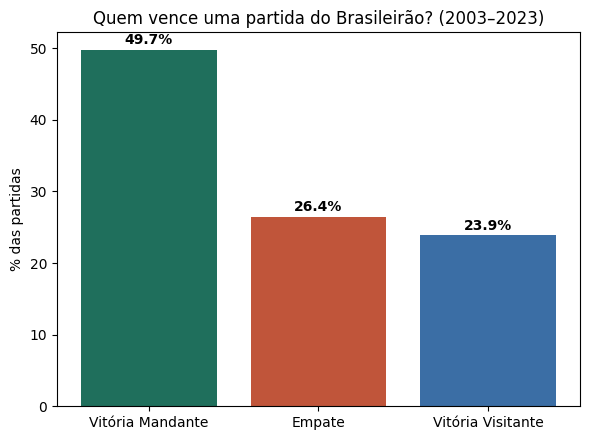

In [29]:
contagem = tratado["resultado"].value_counts()[["Vitória Mandante", "Empate", "Vitória Visitante"]]
pct = contagem / contagem.sum() * 100
print(pct.round(1))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(contagem.index, pct.values, color=COLORS[:3])
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f"{p:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("% das partidas")
ax.set_title("Quem vence uma partida do Brasileirão? (2003–2023)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/distribuicao_de_resultados.png", dpi=150)
plt.show()


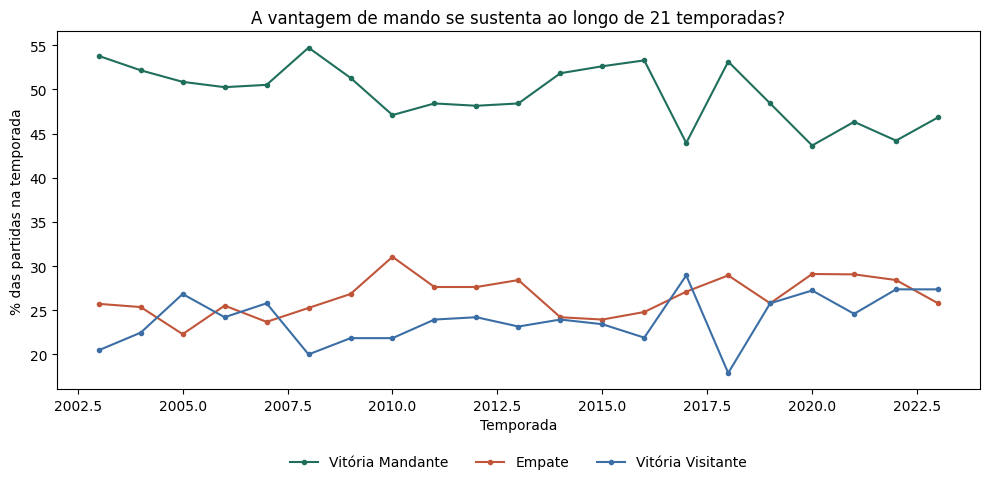

Vitória do mandante — mín: 43.7% (2020) | máx: 54.7% (2008) | dp: 3.3 p.p.
Temporadas com mandante à frente: 21 de 21


In [30]:
res_ano = tratado.groupby(["ano", "resultado"]).size().unstack(fill_value=0)
res_ano_pct = res_ano.div(res_ano.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
for col, c in zip(["Vitória Mandante", "Empate", "Vitória Visitante"], COLORS[:3]):
    ax.plot(res_ano_pct.index, res_ano_pct[col], marker="o", ms=3, label=col, color=c)
ax.set_ylabel("% das partidas na temporada")
ax.set_xlabel("Temporada")
ax.set_title("A vantagem de mando se sustenta ao longo de 21 temporadas?")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mando_ao_longo_do_tempo.png", dpi=150)
plt.show()

vm = res_ano_pct["Vitória Mandante"]
print(f"Vitória do mandante — mín: {vm.min():.1f}% ({vm.idxmin()}) | "
      f"máx: {vm.max():.1f}% ({vm.idxmax()}) | dp: {vm.std():.1f} p.p.")
print(f"Temporadas com mandante à frente: "
      f"{(vm > res_ano_pct['Vitória Visitante']).sum()} de {len(res_ano_pct)}")


### Resultado

Vitória do mandante **49,7%**, empate 26,4%, vitória do visitante **23,9%** — o mandante vence **2,08×** mais.

A taxa varia de 43,7% (2020) a 54,7% (2008), com desvio-padrão de 3,3, e o mandante ficou à frente do visitante em **21 das 21 temporadas**.

**Ressalva que a própria série impõe:** a temporada de menor vantagem é 2020, o que sugere efeito dos jogos sem público — mas 2017 registra 43,9%, praticamente o mesmo valor, com estádios cheios. Este gráfico, sozinho, **não estabelece nada** sobre o efeito da torcida.

**Por que o mandante venceria mais?** A literatura de economia do esporte aponta quatro mecanismos, e eles não são excludentes:

- **Familiaridade** — conhecer as dimensões do gramado, o comportamento da bola, o vestiário e a rotina do dia de jogo.
- **Deslocamento** — o visitante viaja, dorme fora e chega com menos tempo de preparação. Num país de dimensões continentais, isso varia muito por confronto.
- **Torcida sobre os jogadores** — apoio ao mandante e pressão sobre o visitante.
- **Torcida sobre a arbitragem** — pressão do público influenciando decisões marginais.


## 7. A vantagem dos mandantes está encolhendo?

A Seção 6 mediu a vantagem em frequência de vitórias. Aqui medimos em gols, separando as médias do mandante e do visitante por temporada e plotando a diferença entre elas.

A versão anterior desta análise somava os dois lados, o que tornava o mando invisível no gráfico.

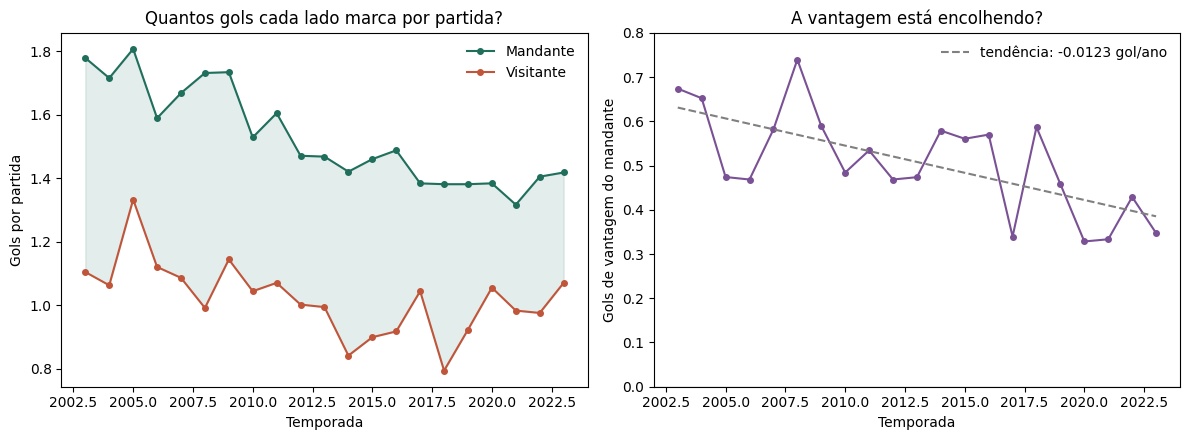

Vantagem média 2003-2009: 0.597 gol
Vantagem média 2017-2023: 0.403 gol
Queda na tendência linear: -0.246 gol em 21 temporadas


In [31]:
gols_ano = tratado.groupby("ano")[["gols_mandante", "gols_visitante"]].mean()
gols_ano["vantagem"] = gols_ano["gols_mandante"] - gols_ano["gols_visitante"]

anos = gols_ano.index.values.astype(float)
coef = np.polyfit(anos, gols_ano["vantagem"].values, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(gols_ano.index, gols_ano["gols_mandante"], marker="o", ms=4,
             color=COLORS[0], label="Mandante")
axes[0].plot(gols_ano.index, gols_ano["gols_visitante"], marker="o", ms=4,
             color=COLORS[1], label="Visitante")
axes[0].fill_between(gols_ano.index, gols_ano["gols_visitante"],
                     gols_ano["gols_mandante"], color=COLORS[0], alpha=0.12)
axes[0].set_title("Quantos gols cada lado marca por partida?")
axes[0].set_xlabel("Temporada"); axes[0].set_ylabel("Gols por partida")
axes[0].legend(frameon=False)

axes[1].plot(gols_ano.index, gols_ano["vantagem"], marker="o", ms=4, color=COLORS[4])
axes[1].plot(gols_ano.index, np.polyval(coef, anos), ls="--", color="gray",
             label=f"tendência: {coef[0]:+.4f} gol/ano")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("A vantagem está encolhendo?")
axes[1].set_xlabel("Temporada"); axes[1].set_ylabel("Gols de vantagem do mandante")
axes[1].set_ylim(0, 0.8)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/vantagem_gols_temporada.png", dpi=150)
plt.show()

print(f"Vantagem média 2003-2009: {gols_ano.loc[2003:2009, 'vantagem'].mean():.3f} gol")
print(f"Vantagem média 2017-2023: {gols_ano.loc[2017:2023, 'vantagem'].mean():.3f} gol")
print(f"Queda na tendência linear: {coef[0]*20:+.3f} gol em 21 temporadas")

### Resultado

O mandante marca em média **0,51 gol a mais** por partida. A vantagem caiu de **0,597** gol (2003–2009) para **0,403** gol (2017–2023) — redução de ~33%, com tendência de −0,0123 gol por ano. Positiva em todas as 21 temporadas.

**Hipóteses para o encolhimento**:
- Profissionalização logística — voos fretados e concentração reduziram o desgaste da viagem.
- Padronização dos estádios após a Copa de 2014, reduzindo a vantagem de familiaridade.
- VAR (2018 em diante), que pode ter reduzido o componente de arbitragem.
- Retração ofensiva geral — os gols do mandante caem mais que os do visitante, então parte do efeito pode ser só futebol mais defensivo.

**O que não permite concluir:** qual dessas causas opera. As quatro são simultâneas e correlacionadas com o tempo; com uma única série agregada são indistinguíveis.

## 7.2 Comparação do mesmo placar, invertendo o mando

Comparando cada placar com seu espelho: 2×1 contra 1×2 é o mesmo jogo, mudando apenas quem estava em casa. Se o mando não importasse, os dois ocorreriam com a mesma frequência — toda diferença entre eles é atribuível ao mando, sem precisar de modelo nenhum.

O heatmap dá o panorama de todos os placares; as barras seguintes isolam os pares espelhados.

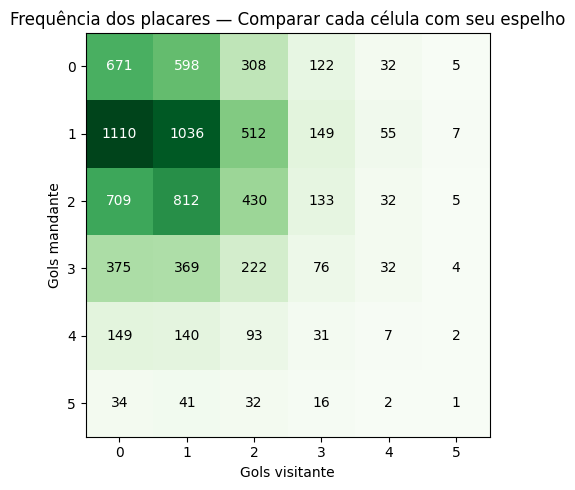

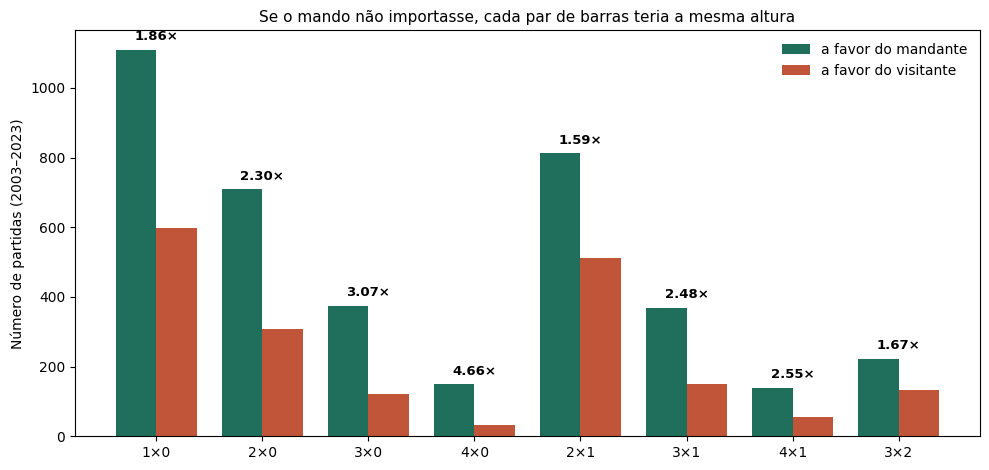

1×0:  1110  |  0×1:   598  |  razão 1.86
2×0:   709  |  0×2:   308  |  razão 2.30
3×0:   375  |  0×3:   122  |  razão 3.07
4×0:   149  |  0×4:    32  |  razão 4.66
2×1:   812  |  1×2:   512  |  razão 1.59
3×1:   369  |  1×3:   149  |  razão 2.48
4×1:   140  |  1×4:    55  |  razão 2.55
3×2:   222  |  2×3:   133  |  razão 1.67


In [32]:
placar = tratado.groupby(["gols_mandante", "gols_visitante"]).size().unstack(fill_value=0).iloc[:6, :6]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(placar.values, cmap="Greens")
ax.set_xticks(range(len(placar.columns))); ax.set_xticklabels(placar.columns)
ax.set_yticks(range(len(placar.index))); ax.set_yticklabels(placar.index)
for i in range(len(placar.index)):
    for j in range(len(placar.columns)):
        v = placar.values[i, j]
        ax.text(j, i, v, ha="center", va="center",
                color="white" if v > placar.values.max() * 0.5 else "black")
ax.set_xlabel("Gols visitante"); ax.set_ylabel("Gols mandante")
ax.set_title("Frequência de placares mais comuns")
plt.tight_layout()
ax.set_title("Frequência dos placares — Comparar cada célula com seu espelho")
plt.savefig(f"{FIG_DIR}/placares_comuns.png", dpi=150)
plt.show()


pares = [(1,0), (2,0), (3,0), (4,0), (2,1), (3,1), (4,1), (3,2)]
contagem_placar = tratado.groupby(["gols_mandante", "gols_visitante"]).size()

a_favor = [contagem_placar.get((a, b), 0) for a, b in pares]   # mandante vence
contra  = [contagem_placar.get((b, a), 0) for a, b in pares]   # visitante vence
rotulos = [f"{a}×{b}" for a, b in pares]

x = np.arange(len(pares)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - w/2, a_favor, w, label="a favor do mandante", color=COLORS[0])
ax.bar(x + w/2, contra,  w, label="a favor do visitante", color=COLORS[1])

for i, (p, c) in enumerate(zip(a_favor, contra)):
    ax.text(i, max(p, c) + 28, f"{p/c:.2f}×", ha="center", fontweight="bold", fontsize=9.5)

ax.set_xticks(x); ax.set_xticklabels(rotulos)
ax.set_ylabel("Número de partidas (2003–2023)")
ax.set_title("Se o mando não importasse, cada par de barras teria a mesma altura", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/assimetria_placares.png", dpi=150)
plt.show()

for (a, b), p, c in zip(pares, a_favor, contra):
    print(f"{a}×{b}: {p:5d}  |  {b}×{a}: {c:5d}  |  razão {p/c:.2f}")

### Resultado

Nenhum par é simétrico, e a razão **cresce com a margem**:

| Placar | Mandante | Visitante | Razão |
|---|---|---|---|
| 1×0 | 1.110 | 598 | 1,86× |
| 2×0 | 709 | 308 | 2,30× |
| 3×0 | 375 | 122 | 3,07× |
| 4×0 | 149 | 32 | **4,66×** |

Isso quer dizer que o mando não decide no detalhe os jogos. Se fosse só isso, a razão seria alta em 1×0 e cairia para ~1 nas margens largas — o padrão é o oposto. Sugere um efeito que se acumula durante a partida: pressão territorial sustentada, adversário que se retrai após sofrer o primeiro gol.

No agregado: mandante vence 4.179 vezes, visitante 2.005, com 2.221 empates.

**Ressalva:** nas margens mais largas o número de partidas é pequeno (4×0 ocorre 149 vezes; 0×4, apenas 32).

**O que não permite concluir:** que o mando *causa* goleadas. Se times fortes tivessem mais jogos em casa contra times fracos, o padrão apareceria sem efeito de mando algum. A Seção 9 e o pareamento por adversário atacam isso.

## 8. Como o mandante joga diferente

As seções anteriores mostram *que* o mandante vence mais. Esta começa a mostrar *por quê*.

Comparando mandante e visitante em três blocos — volume (chutes, escanteios), controle (posse, passes) e disciplina (faltas, cartões) — porque cada um discrimina um mecanismo diferente.

Janela de estatísticas: 3419 partidas (2015–2023)

                 Mandante  Visitante  razão M/V
chutes              14.52      11.10       1.31
chutes_no_alvo       3.81       2.88       1.32
posse_de_bola       51.72      48.28       1.07
passes             431.30     406.84       1.06
faltas              14.85      14.84       1.00
impedimentos         1.70       1.54       1.10
escanteios           5.91       4.49       1.32
cartao_amarelo       2.24       2.50       0.90
cartao_vermelho      0.11       0.15       0.70

Taxa de conversão (no alvo / chutes): Mandante 26.2%  |  Visitante 25.9%
Faltas cometidas por cartão amarelo: Mandante 6.62  |  Visitante 5.94


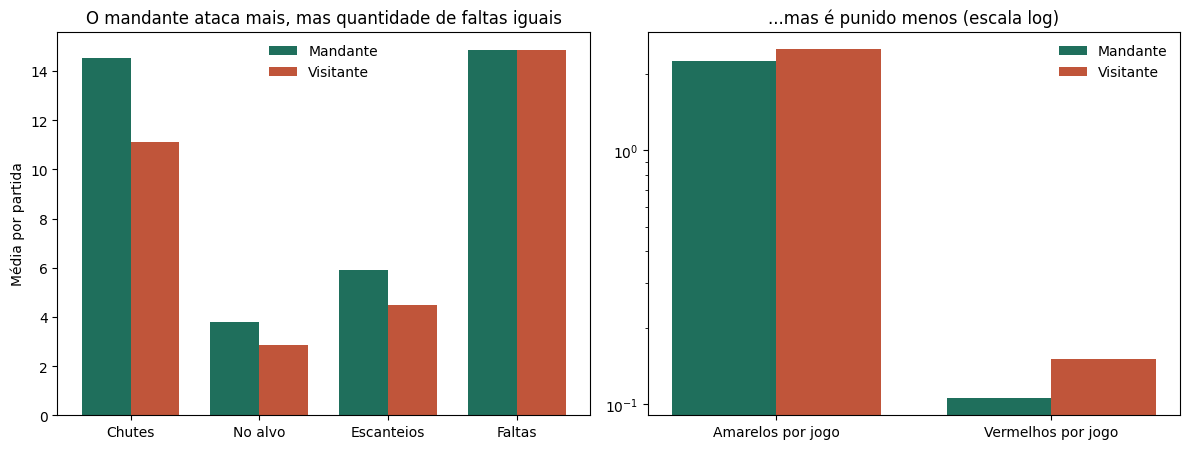

In [33]:
METRICAS = ["chutes", "chutes_no_alvo", "posse_de_bola", "passes",
            "faltas", "impedimentos", "escanteios"]

# A janela sai do próprio dado: linhas onde as estatísticas foram coletadas.
# O tratamento da Seção 4 já marcou as demais como NaN, então .mean() as ignora.
janela = tratado[tratado["faltas_mandante"].notna()]
print(f"Janela de estatísticas: {len(janela)} partidas "
      f"({janela['ano'].min()}–{janela['ano'].max()})\n")

resumo = pd.DataFrame({
    "Mandante":  [tratado[f"{m}_mandante"].mean()  for m in METRICAS],
    "Visitante": [tratado[f"{m}_visitante"].mean() for m in METRICAS],
}, index=METRICAS)
resumo.loc["cartao_amarelo"]  = [janela["cartao_amarelo_mandante"].mean(),
                                 janela["cartao_amarelo_visitante"].mean()]
resumo.loc["cartao_vermelho"] = [janela["cartao_vermelho_mandante"].mean(),
                                 janela["cartao_vermelho_visitante"].mean()]
resumo["razão M/V"] = (resumo["Mandante"] / resumo["Visitante"]).round(3)
print(resumo.round(2))

conv_m = tratado["chutes_no_alvo_mandante"].mean()  / tratado["chutes_mandante"].mean()  * 100
conv_v = tratado["chutes_no_alvo_visitante"].mean() / tratado["chutes_visitante"].mean() * 100
print(f"\nTaxa de conversão (no alvo / chutes): Mandante {conv_m:.1f}%  |  Visitante {conv_v:.1f}%")

fpa_m = janela["faltas_mandante"].sum()  / janela["cartao_amarelo_mandante"].sum()
fpa_v = janela["faltas_visitante"].sum() / janela["cartao_amarelo_visitante"].sum()
print(f"Faltas cometidas por cartão amarelo: Mandante {fpa_m:.2f}  |  Visitante {fpa_v:.2f}")

metricas_plot = ["chutes", "chutes_no_alvo", "escanteios", "faltas"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.arange(len(metricas_plot)); w = 0.38

axes[0].bar(x - w/2, resumo.loc[metricas_plot, "Mandante"],  w, label="Mandante",  color=COLORS[0])
axes[0].bar(x + w/2, resumo.loc[metricas_plot, "Visitante"], w, label="Visitante", color=COLORS[1])
axes[0].set_xticks(x); axes[0].set_xticklabels(["Chutes", "No alvo", "Escanteios", "Faltas"])
axes[0].set_ylabel("Média por partida")
axes[0].set_title("O mandante ataca mais, mas quantidade de faltas iguais")
axes[0].legend(frameon=False)

x2 = np.arange(2)
axes[1].bar(x2 - w/2, resumo.loc[["cartao_amarelo", "cartao_vermelho"], "Mandante"],  w,
            label="Mandante", color=COLORS[0])
axes[1].bar(x2 + w/2, resumo.loc[["cartao_amarelo", "cartao_vermelho"], "Visitante"], w,
            label="Visitante", color=COLORS[1])
axes[1].set_xticks(x2); axes[1].set_xticklabels(["Amarelos por jogo", "Vermelhos por jogo"])
axes[1].set_yscale("log")
axes[1].set_title("...mas é punido menos (escala log)")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/estatisticas_mandante_visitante.png", dpi=150)
plt.show()


### Resultado

Janela: 3.419 partidas (2015–2023)

| Métrica | Mandante | Visitante | Razão M/V |
|---|---|---|---|
| Chutes | 14,52 | 11,10 | 1,31 |
| Chutes no alvo | 3,81 | 2,88 | 1,32 |
| Escanteios | 5,91 | 4,49 | 1,32 |
| Passes | 431,3 | 406,8 | 1,06 |
| Posse de bola | 51,7% | 48,3% | 1,07 |
| **Faltas** | **14,85** | **14,84** | **1,00** |
| Amarelos/jogo | 2,24 | 2,50 | 0,90 |
| Vermelhos/jogo | 0,106 | 0,150 | **0,70** |

**1. Ataca mais, não melhor.** Chutes, chutes no alvo e escanteios sobem ~31–32%, de forma uniforme. Mas a taxa de conversão é 26,2% contra 25,9%, ou seja, praticamente idêntica. O mandante não tem pontaria melhor em casa; chuta mais vezes. Como é o mesmo elenco que joga fora, pode ser relacionado à pressão territorial.

**2. A posse quase não muda.** 51,7% × 48,3% não é uma diferença tão grande diante de um diferencial de vitórias de 2,08×. Enfraquece a explicação "o mandante controla o jogo" e fortalece "o mandante arrisca mais".

**3. Faltas idênticas, punição desigual.** 14,85 contra 14,84 — diferença de 0,01 falta por jogo Mas o visitante recebe **11,4% mais amarelos** e **42,0% mais vermelhos**. Normalizando: **o visitante é advertido a cada 5,94 faltas; o mandante, a cada 6,62.**

**Hipóteses:**
- (a) Viés de arbitragem sob pressão de torcida — hipótese consolidada na literatura de economia do esporte.
- (b) As faltas do visitante são qualitativamente diferentes — um time que defende mais falta em transição, o que é mais punível por regra.
- (c) Diferença de comportamento — reclamação e cartões por dissidência são mais frequentes em quem está perdendo, e o visitante perde mais.

**Consequência:** as três hipóteses fazem previsões diferentes sobre os portões fechados. Se (a) dominar, o diferencial de cartões deve encolher sem torcida. Se (b) ou (c) dominarem, deve permanecer — nem tática nem comportamento dependem de público.

## 9. O mando vale o mesmo para todo clube?

A Seção 6 mediu o mando no agregado. Restam duas questões:

**Primeira:** e se o efeito viesse da composição dos confrontos, e não do mando? Para separar, usamos cada clube como seu próprio controle — aproveitamento em casa menos aproveitamento fora, nas mesmas temporadas. Como é o mesmo elenco, a mesma comissão e o mesmo orçamento nos dois cenários, a qualidade do time se cancela na subtração.

**Segunda:** times mais fortes se beneficiam mais do mando? É uma intuição comum — estádio cheio, torcida que pressiona — e ela é testável cruzando a vantagem de cada clube com a sua força geral.

32 clubes | diferencial médio: 25.6 p.p. (dp 4.9) | amplitude: 11.3 a 35.4 p.p.

               jogos_casa  apr_casa  apr_fora  delta
mandante                                            
Atletico-GO           133      42.6      31.3   11.3
Chapecoense           132      45.7      26.6   19.1
Avai                  133      44.4      23.6   20.8
Cruzeiro              352      61.6      40.3   21.3
Botafogo-RJ           349      55.3      33.8   21.5
Bragantino             76      57.9      36.4   21.5
Vasco                 314      53.9      32.1   21.9
Flamengo              408      63.4      41.2   22.2
Fluminense            409      59.2      36.9   22.2
Palmeiras             367      64.9      42.0   23.0
Corinthians           390      63.4      39.7   23.7
Sao Caetano            86      57.8      33.7   24.0
Figueirense           219      53.9      29.8   24.0
Bahia                 213      51.3      27.2   24.1
Sao Paulo             409      66.3      41.6   24.6
Fortaleza         

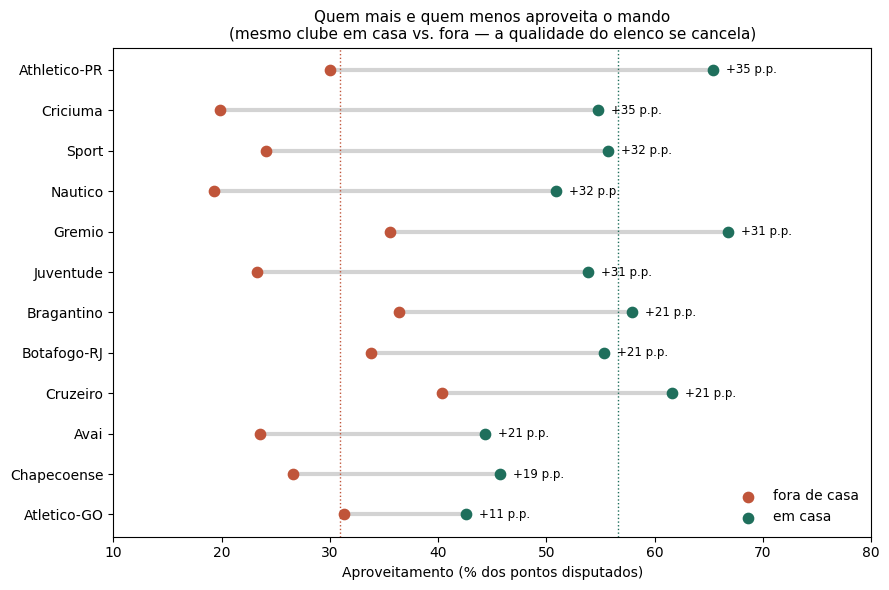

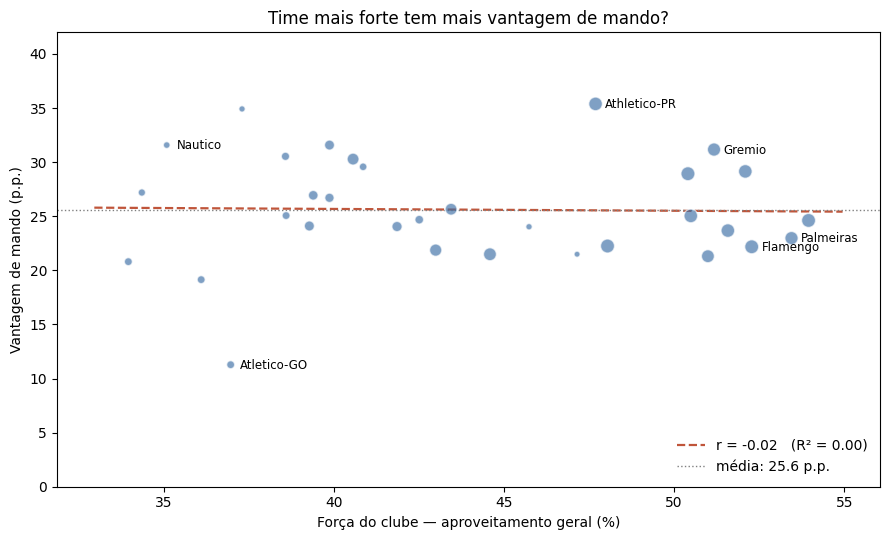

                  n  forca  apr_casa  apr_fora  vantagem
quartil                                                 
Q1 (mais fracos)  8   36.4      48.9      23.8      25.1
Q2                8   40.5      54.1      26.9      27.2
Q3                8   46.3      58.8      33.7      25.1
Q4 (mais fortes)  8   52.0      64.5      39.5      25.0


In [34]:
def pontos(gols_pro, gols_contra):
    return np.where(gols_pro > gols_contra, 3, np.where(gols_pro == gols_contra, 1, 0))

em_casa = (tratado.assign(p=pontos(tratado["gols_mandante"], tratado["gols_visitante"]))
               .groupby("mandante").agg(pts_casa=("p", "sum"), jogos_casa=("p", "size")))
fora    = (tratado.assign(p=pontos(tratado["gols_visitante"], tratado["gols_mandante"]))
               .groupby("visitante").agg(pts_fora=("p", "sum"), jogos_fora=("p", "size")))

clubes = em_casa.join(fora, how="inner")
clubes = clubes[clubes["jogos_casa"] >= 76]
clubes["apr_casa"] = clubes["pts_casa"] / (3 * clubes["jogos_casa"]) * 100
clubes["apr_fora"] = clubes["pts_fora"] / (3 * clubes["jogos_fora"]) * 100
clubes["delta"]    = clubes["apr_casa"] - clubes["apr_fora"]
clubes["forca"]    = ((clubes["pts_casa"] + clubes["pts_fora"]) /
                      (3 * (clubes["jogos_casa"] + clubes["jogos_fora"])) * 100)
clubes["vit_casa"] = tratado[tratado["vencedor"] == tratado["mandante"]]["mandante"].value_counts()
clubes = clubes.sort_values("delta")

print(f"{len(clubes)} clubes | diferencial médio: {clubes['delta'].mean():.1f} p.p. "
      f"(dp {clubes['delta'].std():.1f}) | amplitude: "
      f"{clubes['delta'].min():.1f} a {clubes['delta'].max():.1f} p.p.\n")
print(clubes[["jogos_casa", "apr_casa", "apr_fora", "delta"]].round(1).to_string())

# Por que a contagem bruta de vitórias em casa não mede vantagem de mando
print(f"\nCorrelação da contagem de vitórias em casa com o nº de jogos disputados: "
      f"{clubes['vit_casa'].corr(clubes['jogos_casa']):+.2f}")
print(f"Correlação da contagem de vitórias em casa com a vantagem de mando:      "
      f"{clubes['vit_casa'].corr(clubes['delta']):+.2f}")

sel = pd.concat([clubes.head(6), clubes.tail(6)])
fig, ax = plt.subplots(figsize=(9, 6))
ax.hlines(sel.index, sel["apr_fora"], sel["apr_casa"], color="lightgray", lw=3, zorder=1)
ax.scatter(sel["apr_fora"], sel.index, color=COLORS[1], s=55, label="fora de casa", zorder=2)
ax.scatter(sel["apr_casa"], sel.index, color=COLORS[0], s=55, label="em casa", zorder=2)
for clube, r in sel.iterrows():
    ax.text(r["apr_casa"] + 1.2, clube, f"+{r['delta']:.0f} p.p.", va="center", fontsize=8.5)
ax.axvline(clubes["apr_casa"].mean(), ls=":", color=COLORS[0], lw=1)
ax.axvline(clubes["apr_fora"].mean(), ls=":", color=COLORS[1], lw=1)
ax.set_xlabel("Aproveitamento (% dos pontos disputados)")
ax.set_xlim(10, 80)
ax.set_title("Quem mais e quem menos aproveita o mando\n"
             "(mesmo clube em casa vs. fora — a qualidade do elenco se cancela)", fontsize=11)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/diferencial_mando_clube.png", dpi=150)
plt.show()


r_forca = clubes["forca"].corr(clubes["delta"])
coef_f  = np.polyfit(clubes["forca"], clubes["delta"], 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(clubes["forca"], clubes["delta"], s=clubes["jogos_casa"] / 4,
           color=COLORS[2], alpha=0.65, edgecolor="white", zorder=3)
xs = np.linspace(clubes["forca"].min() - 1, clubes["forca"].max() + 1, 50)
ax.plot(xs, np.polyval(coef_f, xs), ls="--", color=COLORS[1], lw=1.6,
        label=f"r = {r_forca:+.2f}   (R² = {r_forca**2:.2f})", zorder=2)
ax.axhline(clubes["delta"].mean(), ls=":", color="gray", lw=1,
           label=f"média: {clubes['delta'].mean():.1f} p.p.")
for cl in ["Flamengo", "Palmeiras", "Athletico-PR", "Gremio", "Atletico-GO", "Nautico"]:
    if cl in clubes.index:
        ax.annotate(cl, (clubes.loc[cl, "forca"], clubes.loc[cl, "delta"]),
                    textcoords="offset points", xytext=(7, -3), fontsize=8.5)
ax.set_xlabel("Força do clube — aproveitamento geral (%)")
ax.set_ylabel("Vantagem de mando (p.p.)")
ax.set_title("Time mais forte tem mais vantagem de mando?", fontsize=12)
ax.set_ylim(0, 42)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/forca_vs_mando.png", dpi=150)
plt.show()

# Mesma leitura, em quartis de força
clubes["quartil"] = pd.qcut(clubes["forca"], 4,
                            labels=["Q1 (mais fracos)", "Q2", "Q3", "Q4 (mais fortes)"])
print(clubes.groupby("quartil", observed=True)
      .agg(n=("delta", "size"), forca=("forca", "mean"),
           apr_casa=("apr_casa", "mean"), apr_fora=("apr_fora", "mean"),
           vantagem=("delta", "mean")).round(1).to_string())

### Resultado

Diferencial médio de **25,6 p.p.** (dp 4,9), variando de **+11,3 p.p.** (Atlético-GO) a **+35,4 p.p.** (Athletico-PR) entre 32 clubes.

**1. O mando é universal.** Nenhum dos 32 clubes tem diferencial negativo — não existe, na história recente do Brasileirão, time que jogue melhor fora de casa.

**2. Força e vantagem de mando são independentes.** A correlação entre as duas é **r = −0,02 (R² = 0,00)**, ou seja, ausência total de relação. Por quartil de força, o aproveitamento em casa sobe 16 pontos do mais fraco ao mais forte e o de fora sobe 16 pontos: as duas curvas sobem em paralelo e a diferença fica parada em ~25 p.p. Times fortes vencem mais em qualquer lugar, mas o bônus de jogar em casa é o mesmo para todos. Isso desfaz a intuição de que grandes clubes, com estádios cheios, extrairiam mais vantagem do mando.

**3. Por que a contagem bruta de vitórias em casa não serve.** Ela tem correlação de **+0,99 com o número de jogos disputados** e de apenas **+0,09 com a vantagem de mando** — é essencialmente um ranking de permanência na Série A.

**O que não permite concluir:** quais fatores explicam a dispersão que sobra. São características fixas do clube (distância de viagem, clima, altitude, estádio), colineares com a identidade dele

**Ressalva de seleção:** o filtro de ≥76 jogos exclui clubes com passagens curtas pela Série A, que tendem a ser os mais fracos. Os 32 clubes não são uma amostra aleatória do futebol brasileiro.

**Consequência:** a vantagem de mando é um efeito aditivo e uniforme — soma aproximadamente os mesmos 25 p.p. ao aproveitamento de qualquer clube.


## 10. Síntese

Base: 8.405 partidas, 21 temporadas (2003–2023).

**Magnitude**
- Mandante vence 49,7% contra 23,9% do visitante — 2,08× mais, positivo em todas as 21 temporadas.
- Em gols, vantagem de 0,51 gol por partida.
- Em aproveitamento, o mesmo clube rende 25,6 p.p. a mais em casa.

**Estrutura**
- A assimetria cresce com a margem: 1,86× em vitórias por 1×0, 4,66× por 4×0.
- A vantagem encolheu ~33% em 21 temporadas (0,60 → 0,40 gol).
- Universal e uniforme: positiva em 32/32 clubes e independente da força do time (r = −0,02).

**Mecanismo**
- O mandante ataca ~31% mais, com a mesma eficiência de conversão e posse quase simétrica: o efeito é de volume, não de qualidade.
- Faltas idênticas (14,85 × 14,84), mas o visitante recebe 11% mais amarelos e 42% mais vermelhos.

**Limites**
- Estatísticas de jogo só existem em 2015–2023.
- Nada aqui é teste estatístico: nenhum intervalo de confiança foi calculado e nenhuma hipótese de mecanismo foi testada.

### O que fica definido para a próxima etapa

A EDA responde "o mandante vence mais, por uma margem grande", mas não responde a pergunta central, porque não separa efeito de acaso amostral. 
